In [1]:
import sympy as smp

In [2]:
dS, dE, dI, dT = smp.symbols(r'\dot{S} \dot{E} \dot{I} \dot{T}')
S, E, I, T, N = smp.symbols('S E I  T N')
lam, b, c, sig, p, k, m, r, d = smp.symbols(r'\Lambda \beta c \sigma p k \mu r d')

In [3]:
dS = lam - b*c*S*I/N - m*S
dS

-I*S*\beta*c/N - S*\mu + \Lambda

In [4]:
dE = b*c*S*I/N - p*b*c*E*I/N - (m+k)*E + sig*b*c*T*I/N
dE

-E*I*\beta*c*p/N - E*(\mu + k) + I*S*\beta*c/N + I*T*\beta*\sigma*c/N

In [5]:
dI = p*b*c*E*I/N +k*E - (m+ r+ d)*I
dI

E*I*\beta*c*p/N + E*k - I*(\mu + d + r)

In [6]:
dT = r*I - sig*b*c*T*I/N - m*T
dT

I*r - I*T*\beta*\sigma*c/N - T*\mu

In [7]:
S0 = smp.solve(dS.subs([[I,0],[E,0],[N,S]]))[0][S]
S0

\Lambda/\mu

In [8]:
F_full = smp.Matrix([[0],
               [b*c*S*I/N + sig*b*c*T*I/N],
               [0],
               [0]])
F_full

Matrix([
[                                   0],
[I*S*\beta*c/N + I*T*\beta*\sigma*c/N],
[                                   0],
[                                   0]])

In [9]:
V_full = -smp.Matrix([[lam - b*c*S*I/N - m*S],
               [- p*b*c*E*I/N - (m+k)*E],
               [p*b*c*E*I/N +k*E - (m+ r+ d)*I],
               [r*I - sig*b*c*T*I/N - m*T]])
V_full

Matrix([
[         I*S*\beta*c/N + S*\mu - \Lambda],
[           E*I*\beta*c*p/N + E*(\mu + k)],
[-E*I*\beta*c*p/N - E*k + I*(\mu + d + r)],
[     -I*r + I*T*\beta*\sigma*c/N + T*\mu]])

In [10]:
test = (p*b*c*E*I - E*m*N - E*k*N)/N
test

(E*I*\beta*c*p - E*N*\mu - E*N*k)/N

In [11]:
smp.solve(test.subs(N,S+E+I+T),E)[1]

(I*\beta*c*p - I*\mu - I*k - S*\mu - S*k - T*\mu - T*k)/(\mu + k)

In [12]:
badTerm = E*(m+k) + I*(-b*c*p + m +k) + S*(m+k) + T*(m+k)
badTerm

E*(\mu + k) + I*(-\beta*c*p + \mu + k) + S*(\mu + k) + T*(\mu + k)

In [13]:
test2 = (p*b*c*E*I - E*k*N)/N
test2

(E*I*\beta*c*p - E*N*k)/N

In [14]:
smp.solve(test2.subs(N,S+E+I+T),E)[1]

I*\beta*c*p/k - I - S - T

In [15]:
V_ei = smp.Matrix([[2*(m+k),-b*c*p + m + k],
                      [-k, b*c*p - 1/k + m+d+r]])
V_ei

Matrix([
[2*\mu + 2*k,          -\beta*c*p + \mu + k],
[         -k, \beta*c*p + \mu + d + r - 1/k]])

In [16]:
F_ei = smp.Matrix([[0,b],
                   [0,0]])
F_ei

Matrix([
[0, \beta],
[0,     0]])

In [17]:
smp.Matrix.inv(V_ei)

Matrix([
[(\beta*c*k*p + \mu*k + d*k + k*r - 1)/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k), (\beta*c*k*p - \mu*k - k**2)/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k)],
[                                 k**2/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k),           (2*\mu*k + 2*k**2)/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k)]])

In [18]:
smp.Matrix.multiply(F_ei,smp.Matrix.inv(V_ei))

Matrix([
[\beta*k**2/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k), \beta*(2*\mu*k + 2*k**2)/(2*\beta*\mu*c*k*p + \beta*c*k**2*p + 2*\mu**2*k + 2*\mu*d*k + 3*\mu*k**2 + 2*\mu*k*r - 2*\mu + 2*d*k**2 + k**3 + 2*k**2*r - 2*k)],
[                                                                                                                                           0,                                                                                                                                                          0]])

# Part 2, MatCont

In [21]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import odeint

* Plot 2 variables
    * $\sigma<1$
    * $\mathcal{R}_0<1$
    * $\Lambda = 417$
    * $\mu = 0.016$
    * $\sigma = 0.9$
    * $d = 0.1$
    * $k = 0.005$
    * $r=2$
    * $p = 0.4$
* Additional plot 2 Info
    * $p_0=0.3$
    * $\mathcal{R}_0 = 0.87$
    * $\mathcal{R}_p = 0.84$
    * $I_0 = \{50,300,750,900,1100\}$
    * $I_0 = 0$: Stable
    * $I_-^* = 132$: Unstable
    * $I_+^* = 795$: Stable

In [159]:
def SEIT(X,t):
    b = 2.825082508250825
    c = 2.825882588258826
    d=0.1
    p=0.4
    k=0.005
    r=2
    lam=417
    mu=0.01668
    sig=0.9
    
    
    S,E,I,T = X
    N = S + E + I + T 
    

    dS = lam - b*c*S*(I/N) - mu * S
    dE = b*c*S*(I/N) - p*b*c*E*(I/N) - (mu + k)*E + sig*b*c*T*(I/N)
    dI = p*b*c*E*(I/N) + k*E - (mu + r + d)*I
    dT = r*I - sig*b*c*T*(I/N -mu*T)

    return [dS,dE,dI,dT]

def R0(b,c,
       d=0.1,r=2,k=0.005,mu=0.01668):
    # b = -c
    
    return (b*c/(mu+r+d))*(k/(mu+k)) -0.87

In [160]:
b = np.linspace(0,8,10000)
c = b.copy()

bG,cG = np.meshgrid(b,c)

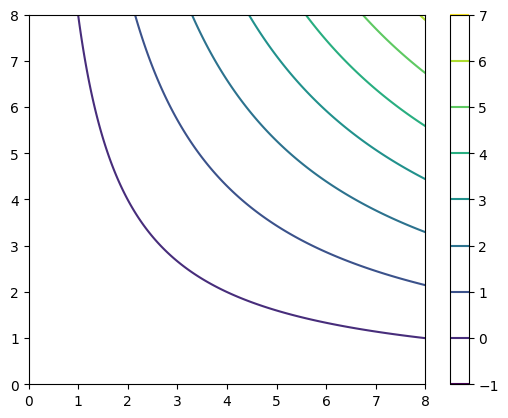

In [161]:
plt.contour(bG,cG,R0(bG,cG))
plt.colorbar()

In [162]:
np.where(np.round(R0(b,c),3)==0)

(array([3531, 3532]),)

In [163]:
b[3531]

np.float64(2.825082508250825)

In [164]:
c[3532]

np.float64(2.825882588258826)

In [165]:
R0(2.8181,2.8181)

-0.004696779505425019

In [166]:
t = np.linspace(0,350,40000)
SEIT0 = [0,0,0,0]
start = 0
b =0.25

In [167]:
I50  = odeint(SEIT,[25000,0,50,0],t)
I50 = I50.T
I50_xlim = [np.min(I50[0])-b,np.max(I50[0])+b]
I50_ylim = [np.min(I50[1])-b,np.max(I50[1])+b]
I50_zlim = [np.min(I50[2])-b,np.max(I50[2])+b]

C:\Users\mdsto\AppData\Local\Temp\ipykernel_14792\3510015011.py:1: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  I50  = odeint(SEIT,[25000,0,50,0],t)


In [168]:
I300  = odeint(SEIT,[25000,0,300,0],t)
I300 = I300.T
I300_xlim = [np.min(I300[0])-b,np.max(I300[0])+b]
I300_ylim = [np.min(I300[1])-b,np.max(I300[1])+b]
I300_zlim = [np.min(I300[2])-b,np.max(I300[2])+b]

C:\Users\mdsto\AppData\Local\Temp\ipykernel_14792\3279409960.py:1: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  I300  = odeint(SEIT,[25000,0,300,0],t)


In [169]:
I750  = odeint(SEIT,[25000,0,750,0],t)
I750 = I750.T
I750_xlim = [np.min(I750[0])-b,np.max(I750[0])+b]
I750_ylim = [np.min(I750[1])-b,np.max(I750[1])+b]
I750_zlim = [np.min(I750[2])-b,np.max(I750[2])+b]

C:\Users\mdsto\AppData\Local\Temp\ipykernel_14792\3931849483.py:1: ODEintWarning: Excess work done on this call (perhaps wrong Dfun type). Run with full_output = 1 to get quantitative information.
  I750  = odeint(SEIT,[25000,0,750,0],t)


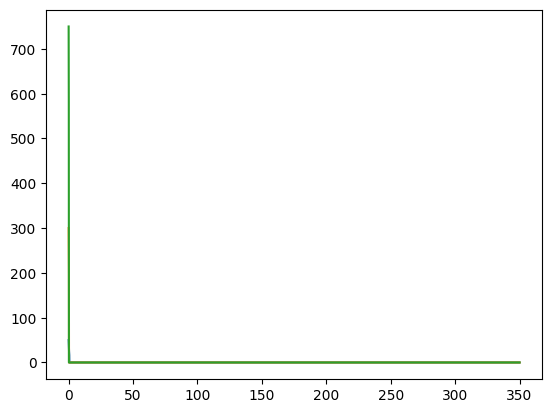

In [170]:
plt.plot(t,I50[-2])
plt.plot(t,I300[-2])
plt.plot(t,I750[-2])

## Symbolic stuff

In [19]:
R0 = b*c/(m+r+d)*k/(m+k)
R0

\beta*c*k/((\mu + k)*(\mu + d + r))

In [30]:
bc = smp.solve(R0- 0.87,b*c)[0]
bc

0.87*(\mu**2 + \mu*d + \mu*r + k*(\mu + d + r))/k

In [31]:
bc= bc.subs([[m,0.016],[d,0.1],[k,0.005],[r,2]])
bc

7.73186400000000

In [32]:
bc = smp.solve(R0- 0.84,b*c)[0]
bc

0.84*(\mu**2 + \mu*d + \mu*r + k*(\mu + d + r))/k

In [33]:
bc = smp.solve(R0- 1,b*c)[0]
bc

(\mu**2 + \mu*d + \mu*r + k*(\mu + d + r))/k

In [34]:
bc= bc.subs([[m,0.016],[d,0.1],[k,0.005],[r,2]])
bc

8.88720000000000

In [37]:
10/(0.016+0.1+2)*0.005/(0.016+0.005)

1.1252137906202178